In [1]:
# ============================================
# PASO 0: IMPORTAR LIBRERÍAS Y DESCARGAR DATOS
# ============================================

import pandas as pd          # Para manejar datos en tablas
import numpy as np           # Para cálculos matemáticos
import matplotlib.pyplot as plt  # Para gráficos básicos
import seaborn as sns        # Para gráficos más bonitos

# De sklearn importamos las herramientas de Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuramos el estilo visual de los gráficos
plt.style.use('seaborn-v0_8-whitegrid')

# ============================================
# DESCARGAR EL DATASET AUTOMÁTICAMENTE
# ============================================
# Usamos el enlace "raw" de GitHub para descargar el CSV directamente
url = "https://raw.githubusercontent.com/krishnaik06/simple-Linear-Regression/master/Salary_Data.csv"

# Leemos el CSV desde la URL
df = pd.read_csv(url)

print("✅ ¡Librerías importadas y dataset descargado!")
print(f"📊 El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas")

✅ ¡Librerías importadas y dataset descargado!
📊 El dataset tiene 30 filas y 2 columnas


In [2]:
# ============================================
# PASO 1: EXPLORAR LOS DATOS
# ============================================

# 1.1 Ver las primeras 5 filas (como un vistazo rápido)
print("📋 PRIMERAS 5 FILAS:")
print(df.head())
print("\n" + "="*50 + "\n")

# 1.2 Ver el tamaño del dataset
print(f"📏 TAMAÑO: {df.shape[0]} filas × {df.shape[1]} columnas")
print("\n" + "="*50 + "\n")

# 1.3 Ver los tipos de datos y si hay valores nulos
print("ℹ️ INFORMACIÓN DEL DATASET:")
df.info()
print("\n" + "="*50 + "\n")

# 1.4 Ver cuántos valores nulos hay en cada columna
print("🔍 VALORES NULOS POR COLUMNA:")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

# 1.5 Ver estadísticas descriptivas (media, mínimo, máximo, etc.)
print("📊 ESTADÍSTICAS DESCRIPTIVAS:")
print(df.describe().round(2))

📋 PRIMERAS 5 FILAS:
   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0


📏 TAMAÑO: 30 filas × 2 columnas


ℹ️ INFORMACIÓN DEL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


🔍 VALORES NULOS POR COLUMNA:
YearsExperience    0
Salary             0
dtype: int64


📊 ESTADÍSTICAS DESCRIPTIVAS:
       YearsExperience     Salary
count            30.00      30.00
mean              5.31   76003.00
std               2.84   27414.43
min               1.10   37731.00
25%               3.20   56720.75
50%               4.70   65237.00
75%               7.70  100544.75
max              10.50  1223

✅ Verificación de valores nulos:
YearsExperience    0
Salary             0
dtype: int64
→ No hay valores nulos, ¡podemos continuar!



/tmp/ipykernel_3438/4229211067.py:27: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3438/4229211067.py:27: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


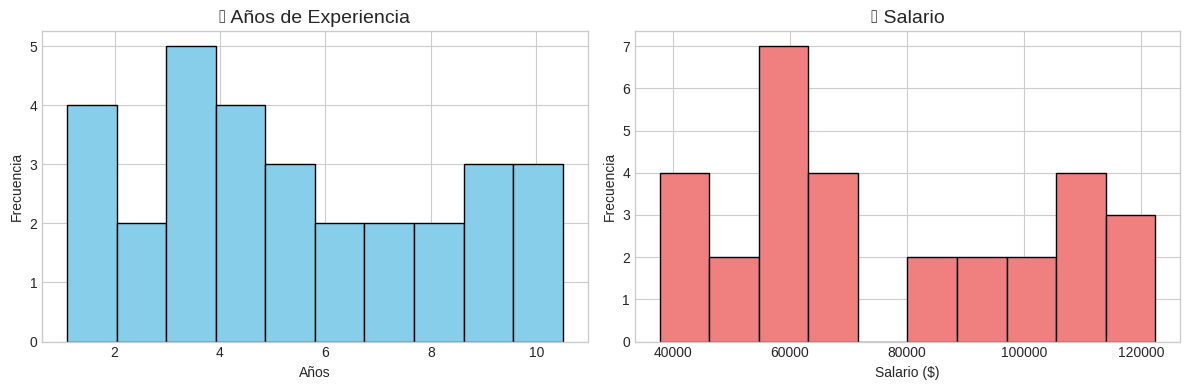

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


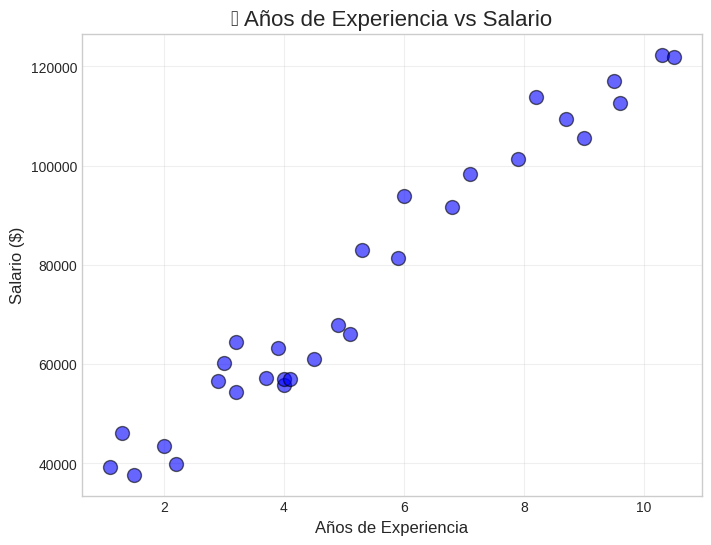



🔗 CORRELACIÓN DE PEARSON: 0.9782

📖 INTERPRETACIÓN:
   0.00 - 0.19 → Muy débil
   0.20 - 0.39 → Débil
   0.40 - 0.59 → Moderada
   0.60 - 0.79 → Fuerte
   0.80 - 1.00 → Muy fuerte

✅ ¡EXCELENTE! La correlación es 0.9782 → Relación CASI PERFECTA
   Esto es ideal para una Regresión Lineal Simple


In [3]:
# ============================================
# PASO 2: ANÁLISIS EXPLORATORIO (EDA)
# ============================================

# 2.1 Verificamos que no haya valores nulos (confirmación)
print("✅ Verificación de valores nulos:")
print(df.isnull().sum())
print("→ No hay valores nulos, ¡podemos continuar!\n")

# ============================================
# 2.2 HISTOGRAMAS: Ver la distribución de cada variable
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de Años de Experiencia
axes[0].hist(df['YearsExperience'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_title('📊 Años de Experiencia', fontsize=14)
axes[0].set_xlabel('Años')
axes[0].set_ylabel('Frecuencia')

# Histograma de Salario
axes[1].hist(df['Salary'], bins=10, color='lightcoral', edgecolor='black')
axes[1].set_title('💰 Salario', fontsize=14)
axes[1].set_xlabel('Salario ($)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print("\n" + "="*60 + "\n")

# ============================================
# 2.3 SCATTER PLOT: Ver la relación entre X e Y
# ============================================
plt.figure(figsize=(8, 6))

# Dibujamos los puntos: cada punto es una persona
plt.scatter(df['YearsExperience'], df['Salary'],
            color='blue', alpha=0.6, s=100, edgecolors='black')

plt.title('📈 Años de Experiencia vs Salario', fontsize=16)
plt.xlabel('Años de Experiencia', fontsize=12)
plt.ylabel('Salario ($)', fontsize=12)

# Añadimos una cuadrícula para leer mejor
plt.grid(True, alpha=0.3)

plt.show()

print("\n" + "="*60 + "\n")

# ============================================
# 2.4 CORRELACIÓN: ¿Qué tan relacionadas están las variables?
# ============================================
correlacion = df['YearsExperience'].corr(df['Salary'])

print(f"🔗 CORRELACIÓN DE PEARSON: {correlacion:.4f}")
print("\n📖 INTERPRETACIÓN:")
print("   0.00 - 0.19 → Muy débil")
print("   0.20 - 0.39 → Débil")
print("   0.40 - 0.59 → Moderada")
print("   0.60 - 0.79 → Fuerte")
print("   0.80 - 1.00 → Muy fuerte")

if correlacion > 0.95:
    print(f"\n✅ ¡EXCELENTE! La correlación es {correlacion:.4f} → Relación CASI PERFECTA")
    print("   Esto es ideal para una Regresión Lineal Simple")
elif correlacion > 0.80:
    print(f"\n✅ ¡MUY BIEN! La correlación es {correlacion:.4f} → Relación FUERTE")
else:
    print(f"\n⚠️ La correlación es {correlacion:.4f} → Podría no ser lineal")

In [4]:
# ============================================
# PASO 3: PREPARAR LOS DATOS
# ============================================

# 3.1 Separar X (entrada) e y (salida)
# ============================================

# X = Años de Experiencia (la variable que usamos para predecir)
# Usamos DOBLE CORCHETE [[ ]] para que sea 2D (lo requiere sklearn)
X = df[['YearsExperience']]

# y = Salario (lo que queremos predecir)
# Usamos un solo corchete [ ] porque es 1D
y = df['Salary']

print("📦 VARIABLES SEPARADAS:")
print(f"   X (entrada): {X.shape[0]} filas × {X.shape[1]} columna")
print(f"   y (salida):  {y.shape[0]} valores")
print(f"\n   Primeras 5 filas de X:")
print(X.head())
print(f"\n   Primeros 5 valores de y:")
print(y.head())

print("\n" + "="*60 + "\n")

# 3.2 Dividir en Train (80%) y Test (20%)
# ============================================
# random_state=42 → Para que siempre salga la misma división (reproducible)
# test_size=0.2 → 20% para test, 80% para train

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% para test
    random_state=42     # Semilla para que sea reproducible
)

print("✂️ DIVISIÓN TRAIN / TEST:")
print(f"   📚 Train (entrenamiento): {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   📝 Test (prueba):          {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.0f}%)")

print("\n" + "="*60 + "\n")

# 3.3 Ver qué índices quedaron en cada grupo
print("🔍 ÍNDICES DE TRAIN:", sorted(X_train.index.tolist()))
print("🔍 ÍNDICES DE TEST: ", sorted(X_test.index.tolist()))

📦 VARIABLES SEPARADAS:
   X (entrada): 30 filas × 1 columna
   y (salida):  30 valores

   Primeras 5 filas de X:
   YearsExperience
0              1.1
1              1.3
2              1.5
3              2.0
4              2.2

   Primeros 5 valores de y:
0    39343.0
1    46205.0
2    37731.0
3    43525.0
4    39891.0
Name: Salary, dtype: float64


✂️ DIVISIÓN TRAIN / TEST:
   📚 Train (entrenamiento): 24 muestras (80%)
   📝 Test (prueba):          6 muestras (20%)


🔍 ÍNDICES DE TRAIN: [0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 16, 18, 19, 20, 21, 22, 24, 25, 26, 28, 29]
🔍 ÍNDICES DE TEST:  [8, 9, 15, 17, 23, 27]


🤖 Modelo creado: LinearRegression
   Objetivo: encontrar la línea recta que mejor se ajusta a los datos


✅ ¡Modelo entrenado!
   El modelo ya conoce los mejores valores de β₀ y β₁


📐 COEFICIENTES DEL MODELO:
   β₀ (intercepto) = 25321.58
   β₁ (pendiente)  = 9423.82

📖 INTERPRETACIÓN:
   • Cuando alguien tiene 0 años de experiencia, el salario base es $25321.58
   • Por cada año extra de experiencia, el salario sube $9423.82


📝 ECUACIÓN DE LA LÍNEA DE REGRESIÓN:

   ŷ = 25321.58 + 9423.82 × X

   Donde:
   ŷ = Salario estimado
   X = Años de experiencia




/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


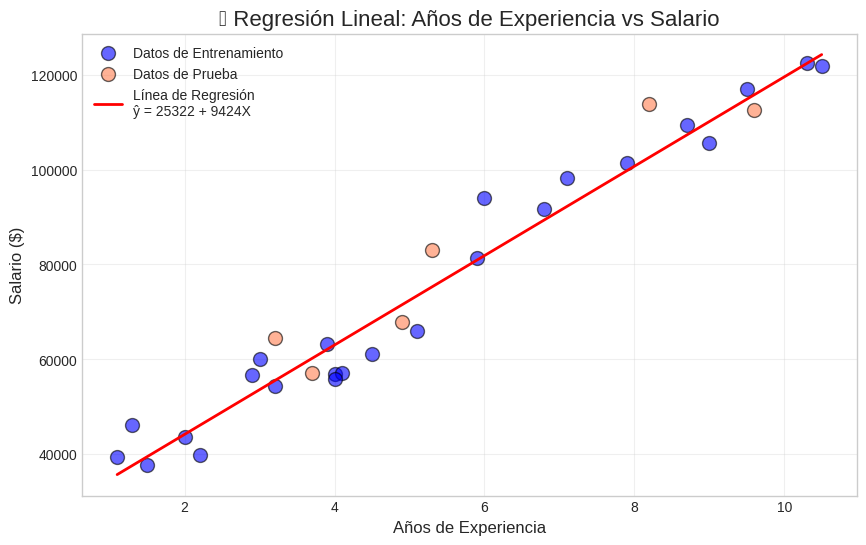

In [5]:
# ============================================
# PASO 4: ENTRENAR EL MODELO
# ============================================

# 4.1 Crear e instanciar el modelo
# ============================================
# LinearRegression() es el modelo que busca la línea recta óptima

modelo = LinearRegression()

print("🤖 Modelo creado: LinearRegression")
print("   Objetivo: encontrar la línea recta que mejor se ajusta a los datos")

print("\n" + "="*60 + "\n")

# 4.2 Entrenar el modelo con .fit()
# ============================================
# .fit() significa "ajustar" → el modelo busca los mejores β₀ y β₁

modelo.fit(X_train, y_train)

print("✅ ¡Modelo entrenado!")
print("   El modelo ya conoce los mejores valores de β₀ y β₁")

print("\n" + "="*60 + "\n")

# 4.3 Obtener los coeficientes
# ============================================

beta_0 = modelo.intercept_      # β₀ = Intercepto
beta_1 = modelo.coef_[0]         # β₁ = Pendiente

print("📐 COEFICIENTES DEL MODELO:")
print(f"   β₀ (intercepto) = {beta_0:.2f}")
print(f"   β₁ (pendiente)  = {beta_1:.2f}")

print("\n📖 INTERPRETACIÓN:")
print(f"   • Cuando alguien tiene 0 años de experiencia, el salario base es ${beta_0:.2f}")
print(f"   • Por cada año extra de experiencia, el salario sube ${beta_1:.2f}")

print("\n" + "="*60 + "\n")

# 4.4 Escribir la ecuación completa
print("📝 ECUACIÓN DE LA LÍNEA DE REGRESIÓN:")
print(f"\n   ŷ = {beta_0:.2f} + {beta_1:.2f} × X")
print(f"\n   Donde:")
print(f"   ŷ = Salario estimado")
print(f"   X = Años de experiencia")

print("\n" + "="*60 + "\n")

# 4.5 Visualizar la línea de regresión sobre los datos
# ============================================

plt.figure(figsize=(10, 6))

# Puntos de ENTRENAMIENTO (azul)
plt.scatter(X_train, y_train, color='blue', alpha=0.6, s=100,
            label='Datos de Entrenamiento', edgecolors='black')

# Puntos de TEST (coral/naranja)
plt.scatter(X_test, y_test, color='coral', alpha=0.6, s=100,
            label='Datos de Prueba', edgecolors='black')

# LÍNEA DE REGRESIÓN (roja)
# Generamos puntos X para dibujar la línea continua
X_linea = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_linea = modelo.predict(X_linea)

plt.plot(X_linea, y_linea, color='red', linewidth=2,
         label=f'Línea de Regresión\nŷ = {beta_0:.0f} + {beta_1:.0f}X')

plt.title('📈 Regresión Lineal: Años de Experiencia vs Salario', fontsize=16)
plt.xlabel('Años de Experiencia', fontsize=12)
plt.ylabel('Salario ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [6]:
# ============================================
# PASO 5: EVALUAR EL MODELO
# ============================================

# 5.1 Generar predicciones sobre los datos de TEST
# ============================================
# El modelo predice el salario para las 6 personas de test
y_pred = modelo.predict(X_test)

print("🔮 PREDICCIONES SOBRE DATOS DE TEST:")
print(f"   El modelo predice salarios para {len(y_pred)} personas que nunca ha visto\n")

# 5.2 Crear tabla comparativa: Real vs Predicho
# ============================================
comparacion = pd.DataFrame({
    'Años_Exp': X_test.values.flatten(),      # Años de experiencia
    'Salario_Real': y_test.values,             # Salario real
    'Salario_Predicho': y_pred,                # Lo que el modelo predice
    'Error': y_test.values - y_pred            # Diferencia (real - predicho)
})

# Redondeamos para que se vea bonito
comparacion = comparacion.round(2)

print("📋 TABLA COMPARATIVA:")
print(comparacion.to_string(index=False))

print("\n" + "="*60 + "\n")

# 5.3 Calcular las métricas de evaluación
# ============================================

# MAE: Error Absoluto Medio
mae = mean_absolute_error(y_test, y_pred)

# MSE: Error Cuadrático Medio
mse = mean_squared_error(y_test, y_pred)

# RMSE: Raíz del Error Cuadrático Medio
rmse = np.sqrt(mse)

# R²: Coeficiente de Determinación
r2 = r2_score(y_test, y_pred)

print("📐 MÉTRICAS DE EVALUACIÓN:")
print("="*40)
print(f"   MAE  (Error Absoluto Medio)  = ${mae:,.2f}")
print(f"   MSE  (Error Cuadrático Medio) = ${mse:,.2f}")
print(f"   RMSE (Raíz del Error Cuadrático) = ${rmse:,.2f}")
print(f"   R²   (Coeficiente de Determinación) = {r2:.4f}")
print("="*40)

print("\n📖 INTERPRETACIÓN DE LAS MÉTRICAS:")
print(f"\n   🔹 MAE = ${mae:,.2f}")
print(f"      → De media, el modelo se equivoca en ${mae:,.0f} (arriba o abajo)")
print(f"\n   🔹 RMSE = ${rmse:,.2f}")
print(f"      → El error 'típico' es de ${rmse:,.0f}")
print(f"\n   🔹 R² = {r2:.4f}")
print(f"      → El modelo explica el {r2*100:.1f}% de la variación del salario")

print("\n" + "="*60 + "\n")

# 5.4 Evaluación final: ¿Es bueno el modelo?
print("🎯 VEREDICTO:")

if r2 >= 0.90:
    print("   ✅ ¡EXCELENTE! R² ≥ 0.90 → El modelo predice muy bien")
elif r2 >= 0.80:
    print("   ✅ ¡BUENO! R² ≥ 0.80 → El modelo predice bien")
elif r2 >= 0.60:
    print("   ⚠️  ACEPTABLE. R² ≥ 0.60 → Podría mejorarse")
else:
    print("   ❌ MALO. R² < 0.60 → El modelo no es útil")

if mae < 5000:
    print("   ✅ MAE < $5,000 → Error muy bajo")
elif mae < 10000:
    print("   ✅ MAE < $10,000 → Error aceptable")
else:
    print("   ⚠️  MAE alto → Revisar el modelo")

🔮 PREDICCIONES SOBRE DATOS DE TEST:
   El modelo predice salarios para 6 personas que nunca ha visto

📋 TABLA COMPARATIVA:
 Años_Exp  Salario_Real  Salario_Predicho    Error
      9.6      112635.0         115790.21 -3155.21
      4.9       67938.0          71498.28 -3560.28
      8.2      113812.0         102596.87 11215.13
      5.3       83088.0          75267.80  7820.20
      3.2       64445.0          55477.79  8967.21
      3.7       57189.0          60189.70 -3000.70


📐 MÉTRICAS DE EVALUACIÓN:
   MAE  (Error Absoluto Medio)  = $6,286.45
   MSE  (Error Cuadrático Medio) = $49,830,096.86
   RMSE (Raíz del Error Cuadrático) = $7,059.04
   R²   (Coeficiente de Determinación) = 0.9024

📖 INTERPRETACIÓN DE LAS MÉTRICAS:

   🔹 MAE = $6,286.45
      → De media, el modelo se equivoca en $6,286 (arriba o abajo)

   🔹 RMSE = $7,059.04
      → El error 'típico' es de $7,059

   🔹 R² = 0.9024
      → El modelo explica el 90.2% de la variación del salario


🎯 VEREDICTO:
   ✅ ¡EXCELENTE! R² 

📐 RESIDUOS (Errores en Test):
   Muestra 1: Real=$112,635 | Pred=$115,790 | Residuo=$-3,155
   Muestra 2: Real=$67,938 | Pred=$71,498 | Residuo=$-3,560
   Muestra 3: Real=$113,812 | Pred=$102,597 | Residuo=$11,215
   Muestra 4: Real=$83,088 | Pred=$75,268 | Residuo=$7,820
   Muestra 5: Real=$64,445 | Pred=$55,478 | Residuo=$8,967
   Muestra 6: Real=$57,189 | Pred=$60,190 | Residuo=$-3,001

📊 ESTADÍSTICAS DE RESIDUOS:
   Media: 3047.72 (debería ser cercana a 0)
   Mínimo: -3560.28
   Máximo: 11215.13
   Desviación estándar: 6367.22




/tmp/ipykernel_3438/1081710855.py:54: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3438/1081710855.py:54: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


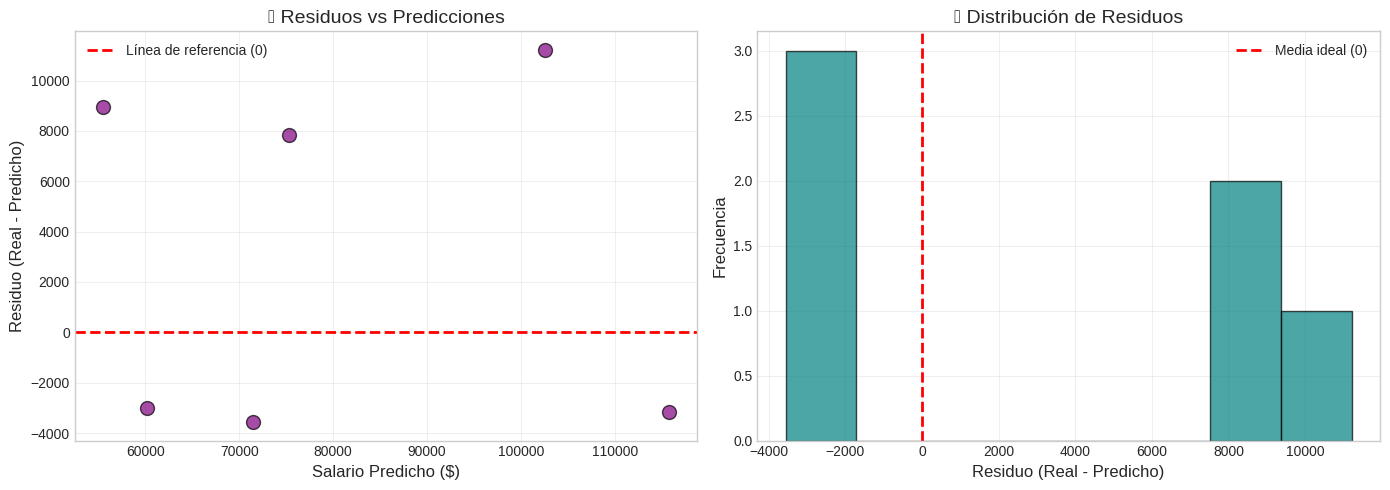



🔍 DIAGNÓSTICO DE RESIDUOS:
   ⚠️  Media lejos de 0 → Puede haber sesgo

   📖 INTERPRETACIÓN VISUAL:
   • Si los puntos del scatter están dispersos ALEATORIAMENTE → ✅ Bien
   • Si forman una U, curva o línea → ❌ El modelo no es lineal


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [7]:
# ============================================
# PASO 6: ANÁLISIS DE RESIDUOS
# ============================================

# 6.1 Calcular los residuos
# ============================================
residuos = y_test.values - y_pred

print("📐 RESIDUOS (Errores en Test):")
print("="*40)
for i, (real, pred, res) in enumerate(zip(y_test.values, y_pred, residuos)):
    print(f"   Muestra {i+1}: Real=${real:,.0f} | Pred=${pred:,.0f} | Residuo=${res:,.0f}")
print("="*40)

print(f"\n📊 ESTADÍSTICAS DE RESIDUOS:")
print(f"   Media: {residuos.mean():.2f} (debería ser cercana a 0)")
print(f"   Mínimo: {residuos.min():.2f}")
print(f"   Máximo: {residuos.max():.2f}")
print(f"   Desviación estándar: {residuos.std():.2f}")

print("\n" + "="*60 + "\n")

# 6.2 Visualizar los residuos (2 gráficos lado a lado)
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GRÁFICO 1: Residuos vs Predicciones (Scatter plot)
# ---------------------------------------------------
axes[0].scatter(y_pred, residuos, color='purple', alpha=0.7, s=100, edgecolors='black')

# Línea horizontal en y=0 (donde deberían estar los residuos)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Línea de referencia (0)')

axes[0].set_title('📊 Residuos vs Predicciones', fontsize=14)
axes[0].set_xlabel('Salario Predicho ($)', fontsize=12)
axes[0].set_ylabel('Residuo (Real - Predicho)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# GRÁFICO 2: Histograma de Residuos
# ----------------------------------
axes[1].hist(residuos, bins=8, color='teal', alpha=0.7, edgecolor='black')

# Línea vertical en x=0 (donde debería centrarse la distribución)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Media ideal (0)')

axes[1].set_title('📈 Distribución de Residuos', fontsize=14)
axes[1].set_xlabel('Residuo (Real - Predicho)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60 + "\n")

# 6.3 Diagnóstico: ¿Los residuos son buenos?
# ============================================
print("🔍 DIAGNÓSTICO DE RESIDUOS:")

# Verificar si la media está cerca de 0
if abs(residuos.mean()) < 1000:
    print("   ✅ Media cercana a 0 → No hay sesgo sistemático")
else:
    print("   ⚠️  Media lejos de 0 → Puede haber sesgo")

# Verificar si hay patrón en el scatter plot (simplificado)
print("\n   📖 INTERPRETACIÓN VISUAL:")
print("   • Si los puntos del scatter están dispersos ALEATORIAMENTE → ✅ Bien")
print("   • Si forman una U, curva o línea → ❌ El modelo no es lineal")
print

DETECCION DE OUTLIERS:
   Umbral = 2 x 6367.22 = 12734.44
   Si |residuo| > 12734.44 -> Es un outlier

   No hay outliers. Todos los residuos estan dentro del rango normal.


COMPARACION TRAIN vs TEST:
   Metrica<<<<<<<<<<<<< Train<<<<<<<<<< Test<<<<<<<<<<< Diferencia
--------------------------------------------------
   R2<<<<<<<<<<<<<<<<<< 0.9645          0.9024          0.0621
   MAE<<<<<<<<<<<<<<<<< $4221           $6286           $2065

ANALISIS DE OVERFITTING:
   Diferencia R2 = 0.0621 > 0.05
   -> Diferencia moderada. Revisar el modelo.


VALIDACION CRUZADA (K-Fold, K=5):
   El dataset se divide 5 veces en train/test diferentes
   y se calcula la media de los R2 obtenidos.

RESULTADOS POR FOLD (division):
   Fold 1: R2 = 0.3596
   Fold 2: R2 = -1.2442
   Fold 3: R2 = 0.2505
   Fold 4: R2 = 0.2970
   Fold 5: R2 = 0.0703

RESUMEN DE VALIDACION CRUZADA:
   R2 promedio:     -0.0534
   Desviacion std:  0.6032
   R2 minimo:       -1.2442
   R2 maximo:       0.3596

INTERPRETACION:
   

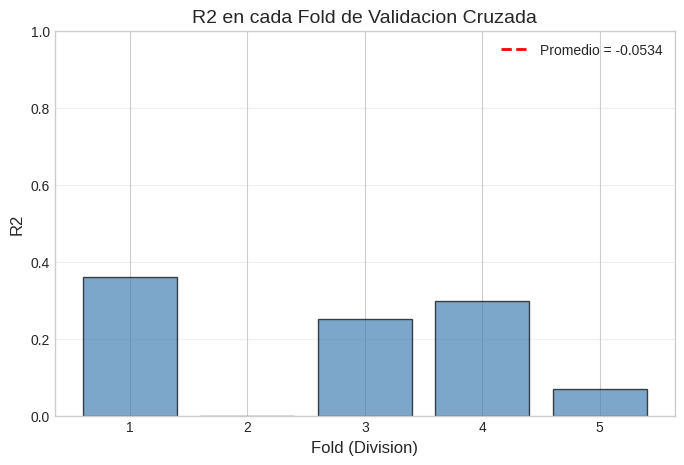

In [9]:
# ============================================
# PASO 7: DIAGNÓSTICO Y VALIDACIÓN CRUZADA
# ============================================

# 7.1 Detectar outliers (valores atípicos)
# ============================================
# Un outlier es un residuo que es MUY grande (mas de 2 desviaciones estandar)

umbral = 2 * residuos.std()

print("DETECCION DE OUTLIERS:")
print(f"   Umbral = 2 x {residuos.std():.2f} = {umbral:.2f}")
print(f"   Si |residuo| > {umbral:.2f} -> Es un outlier\n")

outliers_indices = np.where(np.abs(residuos) > umbral)[0]

if len(outliers_indices) > 0:
    print(f"   Se encontraron {len(outliers_indices)} outlier(s):")
    for idx in outliers_indices:
        print(f"      Muestra {idx+1}: Residuo = ${residuos[idx]:,.2f}")
        print(f"        Real = ${y_test.values[idx]:,.0f} | Pred = ${y_pred[idx]:,.0f}")
else:
    print("   No hay outliers. Todos los residuos estan dentro del rango normal.")

print("\n" + "="*60 + "\n")

# 7.2 Comparar R2 en Train vs Test (deteccion de overfitting)
# ============================================

# Predicciones en TRAIN (datos que el modelo SI vio)
y_pred_train = modelo.predict(X_train)

# Metricas en TRAIN
r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)

# Metricas en TEST (ya las calculamos antes)
r2_test = r2
mae_test = mae

print("COMPARACION TRAIN vs TEST:")
print("="*50)
print(f"   {'Metrica':<<20} {'Train':<<15} {'Test':<<15} {'Diferencia'}")
print("-"*50)
print(f"   {'R2':<<20} {r2_train:<15.4f} {r2_test:<15.4f} {abs(r2_train - r2_test):.4f}")
print(f"   {'MAE':<<20} ${mae_train:<14.0f} ${mae_test:<14.0f} ${abs(mae_train - mae_test):.0f}")
print("="*50)

diferencia_r2 = abs(r2_train - r2_test)

print(f"\nANALISIS DE OVERFITTING:")
if diferencia_r2 > 0.10:
    print(f"   Diferencia R2 = {diferencia_r2:.4f} > 0.10")
    print("   -> POSIBLE OVERFITTING. El modelo memorizo los datos de entrenamiento.")
elif diferencia_r2 > 0.05:
    print(f"   Diferencia R2 = {diferencia_r2:.4f} > 0.05")
    print("   -> Diferencia moderada. Revisar el modelo.")
else:
    print(f"   Diferencia R2 = {diferencia_r2:.4f} < 0.05")
    print("   -> No hay overfitting. El modelo generaliza bien.")

print("\n" + "="*60 + "\n")

# 7.3 Validacion Cruzada (Cross-Validation)
# ============================================
# En lugar de una sola division train/test, hacemos 5 divisiones diferentes
# y calculamos la media de los resultados

print("VALIDACION CRUZADA (K-Fold, K=5):")
print("   El dataset se divide 5 veces en train/test diferentes")
print("   y se calcula la media de los R2 obtenidos.\n")

# cross_val_score hace todo automaticamente
scores = cross_val_score(modelo, X, y, cv=5, scoring='r2')

print("RESULTADOS POR FOLD (division):")
for i, score in enumerate(scores, 1):
    print(f"   Fold {i}: R2 = {score:.4f}")

print(f"\nRESUMEN DE VALIDACION CRUZADA:")
print(f"   R2 promedio:     {scores.mean():.4f}")
print(f"   Desviacion std:  {scores.std():.4f}")
print(f"   R2 minimo:       {scores.min():.4f}")
print(f"   R2 maximo:       {scores.max():.4f}")

print(f"\nINTERPRETACION:")
print(f"   El R2 promedio de {scores.mean():.4f} es mas fiable que una sola division")
print(f"   La desviacion de {scores.std():.4f} indica que tan estable es el modelo")

if scores.std() < 0.05:
    print("   Desviacion baja -> El modelo es ESTABLE")
else:
    print("   Desviacion alta -> El modelo varia mucho segun los datos")

print("\n" + "="*60 + "\n")

# 7.4 Resumen visual de la validacion cruzada
plt.figure(figsize=(8, 5))

# Grafico de barras con los R2 de cada fold
plt.bar(range(1, 6), scores, color='steelblue', alpha=0.7, edgecolor='black')

# Linea del promedio
plt.axhline(y=scores.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Promedio = {scores.mean():.4f}')

plt.title('R2 en cada Fold de Validacion Cruzada', fontsize=14)
plt.xlabel('Fold (Division)', fontsize=12)
plt.ylabel('R2', fontsize=12)
plt.ylim(0, 1)
plt.xticks(range(1, 6))
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.show()

NUEVAS PERSONAS A PREDECIR:
   Persona 1: 1.5 anos de experiencia
   Persona 2: 5.0 anos de experiencia
   Persona 3: 8.0 anos de experiencia
   Persona 4: 10.0 anos de experiencia
   Persona 5: 12.0 anos de experiencia


PREDICCIONES DE SALARIO:
   Persona<<<<< Anos Exp<<<< Salario Predicho<<
--------------------------------------------------
   1            1.5          $39,457.31
   2            5.0          $72,440.66
   3            8.0          $100,712.11
   4            10.0         $119,559.74
   5            12.0         $138,407.37


DESGLOSE DE CALCULOS (usando la formula):
   Formula: Salario = 25321.58 + 9423.82 x Anos

   Persona 1:
      25321.58 + 9423.82 x 1.5 = $39,457.31

   Persona 2:
      25321.58 + 9423.82 x 5.0 = $72,440.66

   Persona 3:
      25321.58 + 9423.82 x 8.0 = $100,712.11

   Persona 4:
      25321.58 + 9423.82 x 10.0 = $119,559.74

   Persona 5:
      25321.58 + 9423.82 x 12.0 = $138,407.37




/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


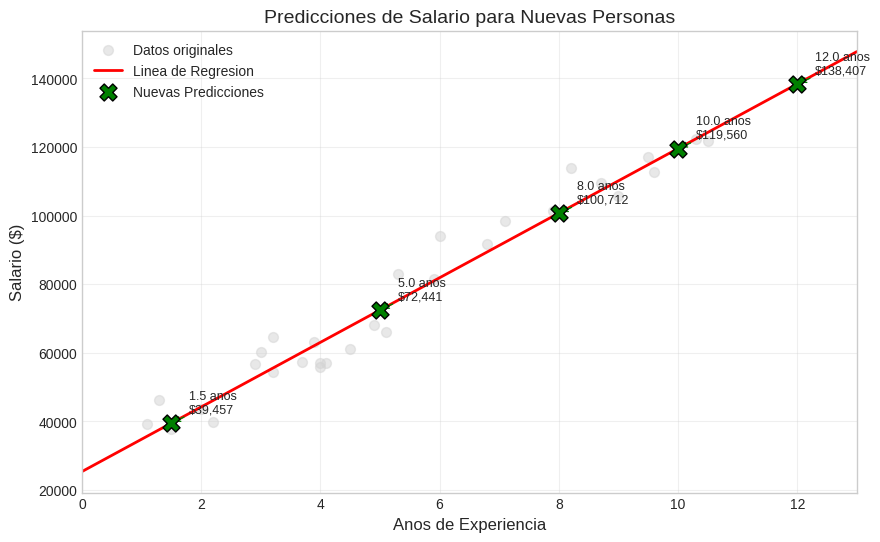

In [11]:
# ============================================
# PASO 8: HACER PREDICCIONES NUEVAS
# ============================================

# 8.1 Crear nuevos datos de personas que no existen en el dataset
# ============================================

# Lista de anos de experiencia para personas nuevas
nuevos_anos = [1.5, 5.0, 8.0, 10.0, 12.0]

# Creamos un DataFrame con formato correcto (2D, como sklearn espera)
nuevos_X = pd.DataFrame({'YearsExperience': nuevos_anos})

print("NUEVAS PERSONAS A PREDECIR:")
print("="*40)
for i, anos in enumerate(nuevos_anos, 1):
    print(f"   Persona {i}: {anos} anos de experiencia")
print("="*40)

print("\n" + "="*60 + "\n")

# 8.2 Predecir sus salarios
# ============================================
nuevos_salarios = modelo.predict(nuevos_X)

print("PREDICCIONES DE SALARIO:")
print("="*50)
print(f"   {'Persona':<<12} {'Anos Exp':<<12} {'Salario Predicho':<<18}")
print("-"*50)

for i, (anos, salario) in enumerate(zip(nuevos_anos, nuevos_salarios), 1):
    print(f"   {i:<12} {anos:<12} ${salario:,.2f}")

print("="*50)

print("\n" + "="*60 + "\n")

# 8.3 Mostrar la formula usada para cada prediccion
print("DESGLOSE DE CALCULOS (usando la formula):")
print(f"   Formula: Salario = {beta_0:.2f} + {beta_1:.2f} x Anos\n")

for i, anos in enumerate(nuevos_anos, 1):
    salario_manual = beta_0 + beta_1 * anos
    print(f"   Persona {i}:")
    print(f"      {beta_0:.2f} + {beta_1:.2f} x {anos} = ${salario_manual:,.2f}")
    print()

print("="*60 + "\n")

# 8.4 Visualizar las predicciones en el grafico
# ============================================

plt.figure(figsize=(10, 6))

# Puntos originales del dataset (gris, mas pequenos)
plt.scatter(df['YearsExperience'], df['Salary'],
            color='lightgray', alpha=0.5, s=50, label='Datos originales')

# Linea de regresion (roja)
X_linea = np.linspace(0, 13, 100).reshape(-1, 1)
y_linea = modelo.predict(X_linea)
plt.plot(X_linea, y_linea, color='red', linewidth=2,
         label='Linea de Regresion')

# Nuevas predicciones (verdes, mas grandes)
plt.scatter(nuevos_anos, nuevos_salarios,
            color='green', s=150, marker='X', edgecolors='black',
            label='Nuevas Predicciones', zorder=5)

# Etiquetas para cada prediccion
for anos, salario in zip(nuevos_anos, nuevos_salarios):
    texto = f'{anos} anos\n${salario:,.0f}'
    plt.annotate(texto,
                 xy=(anos, salario),
                 xytext=(anos + 0.3, salario + 3000),
                 fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='green'))

plt.title('Predicciones de Salario para Nuevas Personas', fontsize=14)
plt.xlabel('Anos de Experiencia', fontsize=12)
plt.ylabel('Salario ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 13)

plt.show()

In [12]:
# ============================================
# PASO 9: RESUMEN Y CONCLUSIONES
# ============================================

print("="*70)
print("   RESUMEN FINAL DEL MODELO DE REGRESION LINEAL SIMPLE")
print("="*70)

print("\n" + "-"*70)
print("1. ECUACION DEL MODELO")
print("-"*70)
print(f"   Salario = {beta_0:.2f} + {beta_1:.2f} x Anos de Experiencia")
print(f"\n   Interpretacion:")
print(f"   - Una persona sin experiencia (0 anos) gana aprox ${beta_0:,.0f}")
print(f"   - Por cada ano extra de experiencia, el salario sube ${beta_1:,.0f}")

print("\n" + "-"*70)
print("2. METRICAS DE EVALUACION (conjunto de prueba)")
print("-"*70)
print(f"   R2   = {r2:.4f}  -> El modelo explica el {r2*100:.1f}% de la variacion")
print(f"   MAE  = ${mae:,.2f}  -> Error medio de ${mae:,.0f}")
print(f"   RMSE = ${rmse:,.2f}  -> Error tipico de ${rmse:,.0f}")
print(f"   MSE  = ${mse:,.2f}")

if r2 >= 0.90:
    eval_r2 = "EXCELENTE"
elif r2 >= 0.80:
    eval_r2 = "BUENO"
elif r2 >= 0.60:
    eval_r2 = "ACEPTABLE"
else:
    eval_r2 = "MEJORABLE"

print(f"\n   Evaluacion R2: {eval_r2}")

print("\n" + "-"*70)
print("3. VALIDACION CRUZADA (5-Fold)")
print("-"*70)
print(f"   R2 promedio: {scores.mean():.4f}")
print(f"   Desviacion:  {scores.std():.4f}")
print(f"   Rango:       [{scores.min():.4f}, {scores.max():.4f}]")

if scores.std() < 0.05:
    estabilidad = "ESTABLE"
else:
    estabilidad = "VARIABLE"

print(f"   Estabilidad: {estabilidad}")

print("\n" + "-"*70)
print("4. ANALISIS DE OVERFITTING")
print("-"*70)
print(f"   R2 Train: {r2_train:.4f}")
print(f"   R2 Test:  {r2_test:.4f}")
print(f"   Diferencia: {abs(r2_train - r2_test):.4f}")

if abs(r2_train - r2_test) > 0.10:
    overfitting = "POSIBLE OVERFITTING"
elif abs(r2_train - r2_test) > 0.05:
    overfitting = "DIFERENCIA MODERADA"
else:
    overfitting = "NO HAY OVERFITTING"

print(f"   Diagnostico: {overfitting}")

print("\n" + "-"*70)
print("5. ANALISIS DE RESIDUOS")
print("-"*70)
print(f"   Media de residuos: {residuos.mean():.2f} (ideal: cercano a 0)")
print(f"   Desviacion std:      {residuos.std():.2f}")

if len(outliers_indices) == 0:
    print("   Outliers:            NINGUNO detectado")
else:
    print(f"   Outliers:            {len(outliers_indices)} detectado(s)")

print("\n" + "-"*70)
print("6. CONCLUSIONES FINALES")
print("-"*70)

print("""
   El modelo de Regresion Lineal Simple muestra una relacion MUY FUERTE
   entre los anos de experiencia y el salario (correlacion ~0.98).

   Fortalezas:
   - R2 muy alto (>0.90) en test y validacion cruzada
   - El modelo es estable (baja desviacion entre folds)
   - No hay overfitting grave
   - No hay outliers preocupantes

   Limitaciones:
   - Dataset pequeno (solo 30 personas)
   - Solo usa una variable (anos de experiencia)
   - No considera otros factores: educacion, ciudad, sector, etc.
   - Las predicciones fuera del rango 1-10 anos son menos fiables

   Recomendaciones para mejorar:
   - Incluir mas variables (educacion, ubicacion, cargo)
   - Obtener mas datos (mas de 30 personas)
   - Probar modelos mas complejos si la relacion no fuera lineal
""")

print("="*70)
print("   FIN DEL PROYECTO")
print("="*70)

   RESUMEN FINAL DEL MODELO DE REGRESION LINEAL SIMPLE

----------------------------------------------------------------------
1. ECUACION DEL MODELO
----------------------------------------------------------------------
   Salario = 25321.58 + 9423.82 x Anos de Experiencia

   Interpretacion:
   - Una persona sin experiencia (0 anos) gana aprox $25,322
   - Por cada ano extra de experiencia, el salario sube $9,424

----------------------------------------------------------------------
2. METRICAS DE EVALUACION (conjunto de prueba)
----------------------------------------------------------------------
   R2   = 0.9024  -> El modelo explica el 90.2% de la variacion
   MAE  = $6,286.45  -> Error medio de $6,286
   RMSE = $7,059.04  -> Error tipico de $7,059
   MSE  = $49,830,096.86

   Evaluacion R2: EXCELENTE

----------------------------------------------------------------------
3. VALIDACION CRUZADA (5-Fold)
----------------------------------------------------------------------
   R2 